In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv("instructor_dataset.csv")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [4]:
df.shape

(2000, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [6]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [7]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

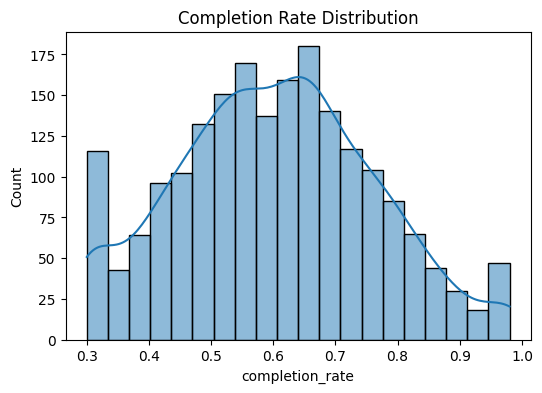

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['completion_rate'], kde=True)
plt.title("Completion Rate Distribution")
plt.show()

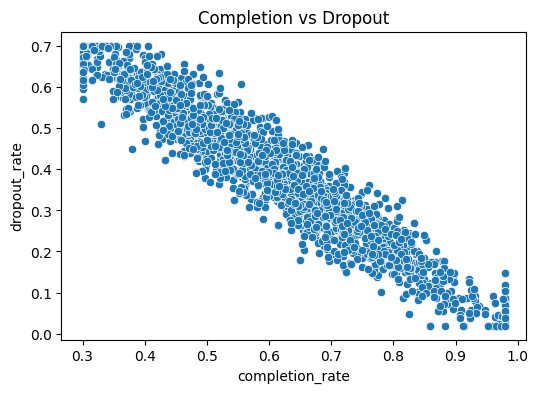

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='completion_rate', y='dropout_rate', data=df)
plt.title("Completion vs Dropout")
plt.show()

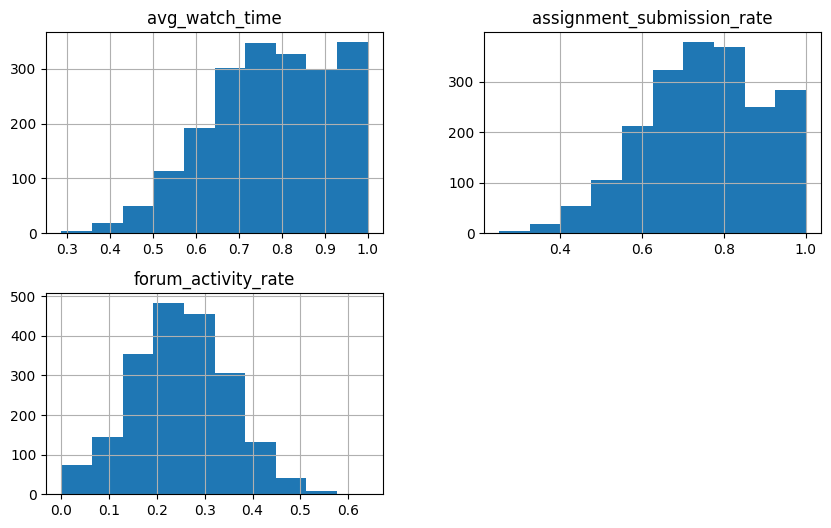

In [11]:
engagement_cols = [
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate'
]

df[engagement_cols].hist(figsize=(10,6))
plt.show()

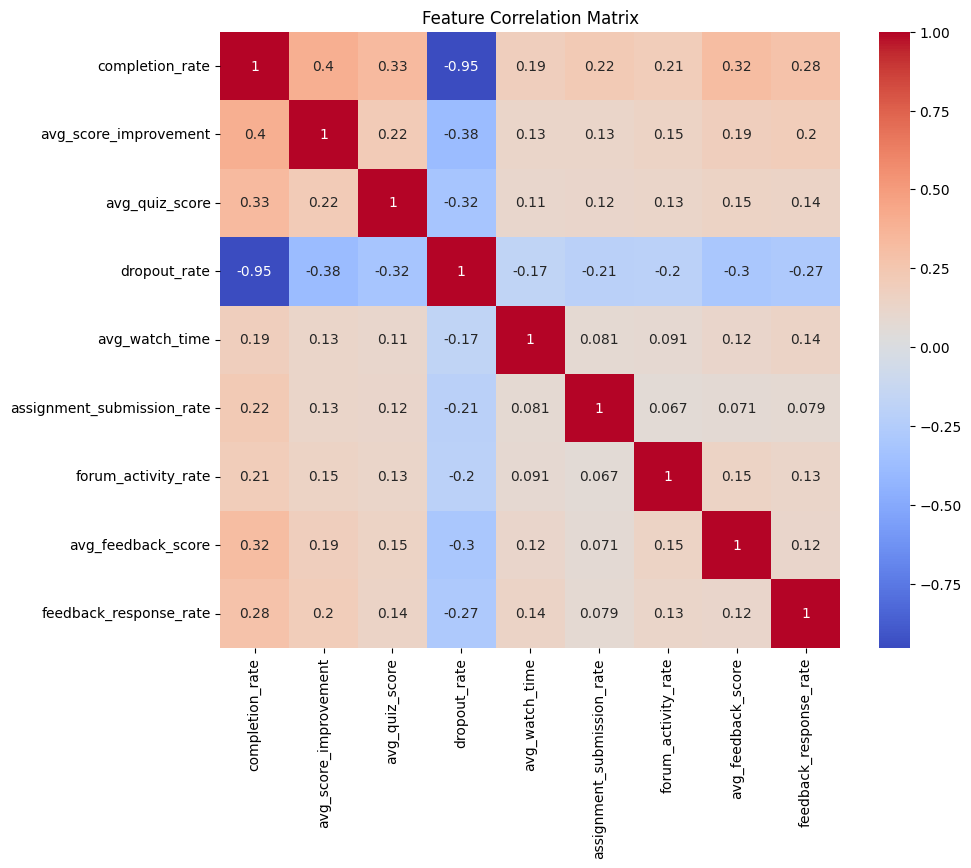

In [14]:
plt.figure(figsize=(10,8))

corr_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")
plt.show()

In [15]:
df['effectiveness_score'] = (
    df['completion_rate']*0.2 +
    df['avg_score_improvement']*0.15 +
    df['avg_quiz_score']*0.15 +
    df['avg_watch_time']*0.1 +
    df['assignment_submission_rate']*0.1 +
    df['forum_activity_rate']*0.1 +
    df['avg_feedback_score']*0.15 -
    df['dropout_rate']*0.15
)

In [16]:
df['effectiveness_tier'] = pd.qcut(
    df['effectiveness_score'],
    q=3,
    labels=['Low','Medium','High']
)

In [18]:
# select only numeric columns
numeric_df = df.select_dtypes(include='number')

# add instructor_id back
numeric_df['instructor_id'] = df['instructor_id']

# group by instructor
instructor_df = numeric_df.groupby('instructor_id').mean().reset_index()

instructor_df.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,16.675494
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,17.736202
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,17.710709
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,15.887659
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,18.748737


In [20]:
numeric_cols = df.select_dtypes(include='number').columns

instructor_df = df.groupby('instructor_id')[numeric_cols].mean().reset_index()

In [21]:
instructor_df['effectiveness_tier'] = pd.qcut(
    instructor_df['effectiveness_score'],
    q=3,
    labels=['Low','Medium','High']
)

In [22]:
X = instructor_df.drop(['instructor_id','effectiveness_tier'], axis=1)
y = instructor_df['effectiveness_tier']

In [23]:
instructor_df['effectiveness_tier'] = pd.qcut(
    instructor_df['effectiveness_score'],
    q=3,
    labels=['Low','Medium','High']
)

In [24]:
X = instructor_df.drop(['instructor_id','effectiveness_tier'], axis=1)
y = instructor_df['effectiveness_tier']

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model.predict(X_test)

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.80      0.89         5
           2       0.92      1.00      0.96        12

    accuracy                           0.96        24
   macro avg       0.97      0.93      0.95        24
weighted avg       0.96      0.96      0.96        24



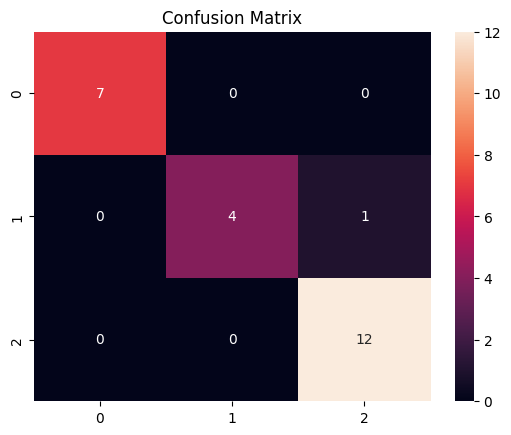

In [30]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True)
plt.title("Confusion Matrix")
plt.show()

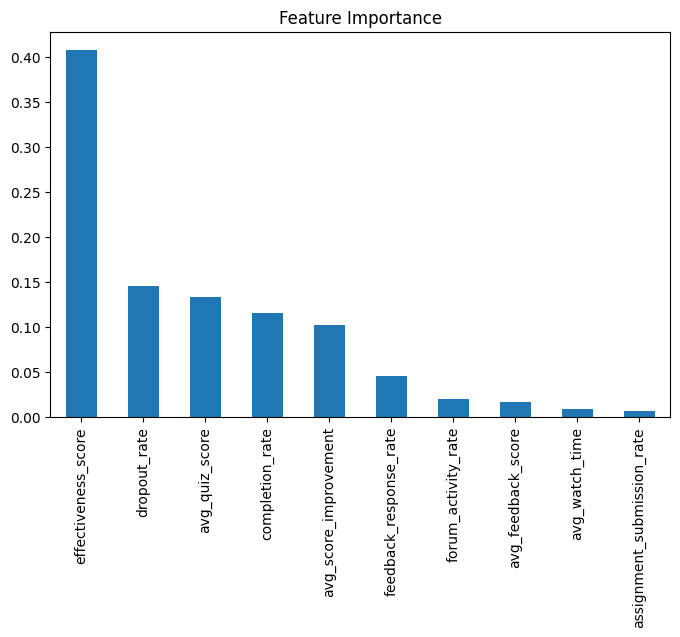

In [31]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.plot(kind='bar', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

This analysis developed an instructor effectiveness framework using learner outcomes, engagement metrics, and feedback data.
Batch-level data was aggregated to instructor level and used to train a Random Forest model to classify instructors into effectiveness tiers.
The results highlight the importance of completion rates, learner engagement, and feedback scores in predicting teaching effectiveness.
However, such models must be used cautiously due to potential biases and confounding factors.

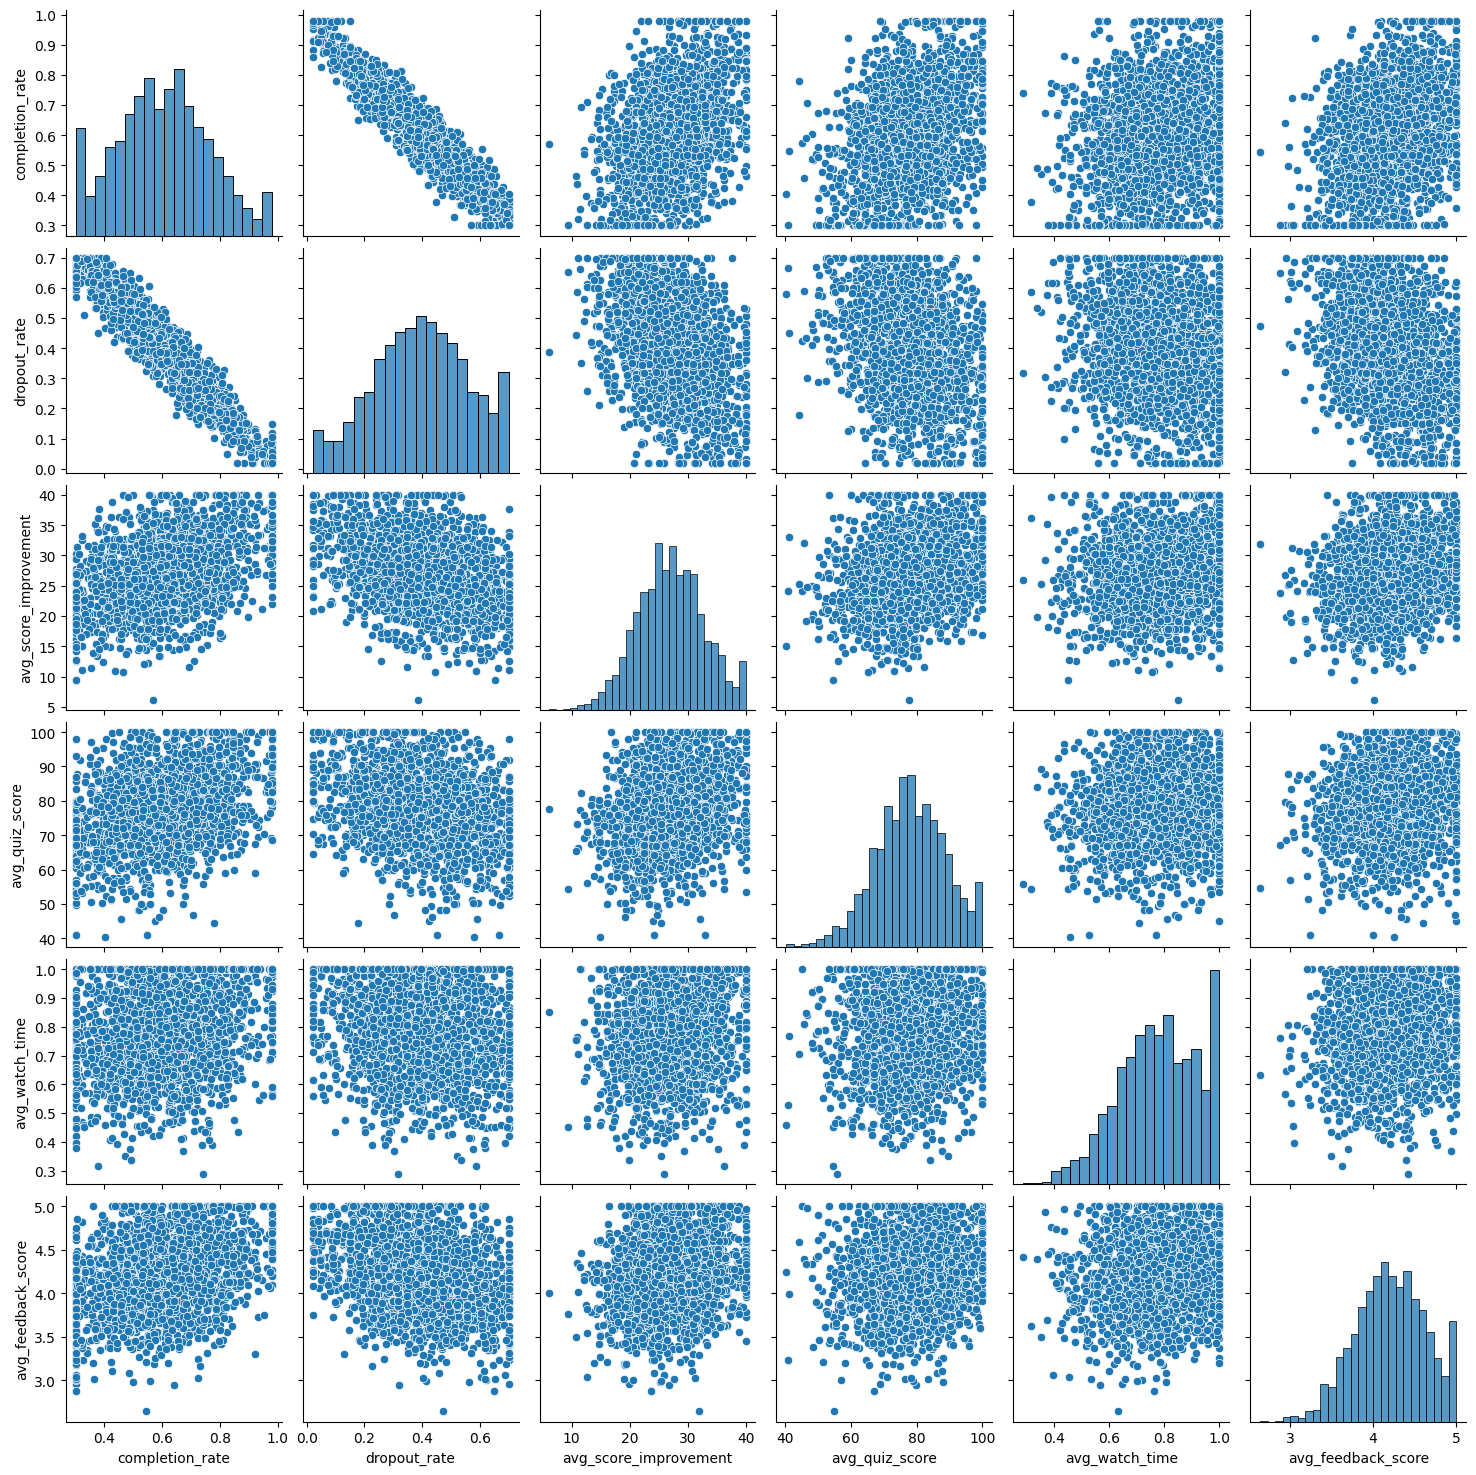

In [32]:
eda_cols = [
    'completion_rate',
    'dropout_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'avg_watch_time',
    'avg_feedback_score'
]

sns.pairplot(df[eda_cols])
plt.show()

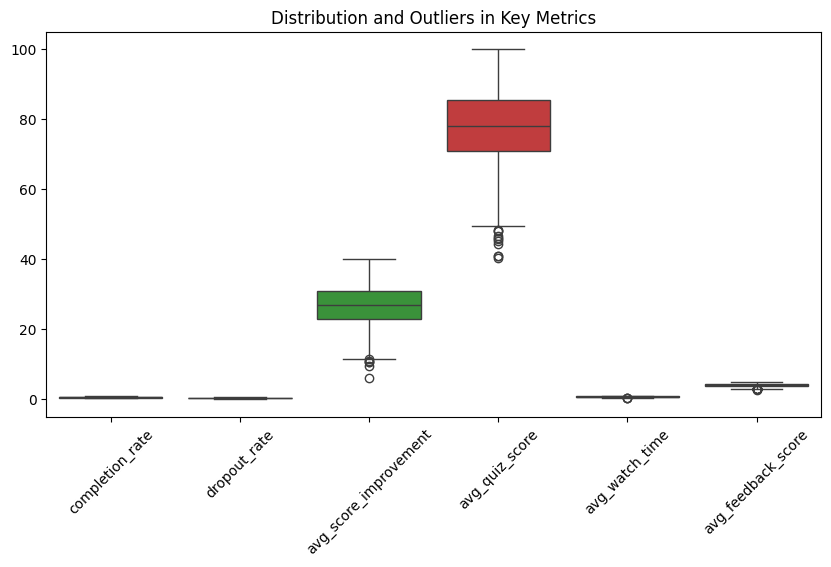

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[eda_cols])
plt.xticks(rotation=45)
plt.title("Distribution and Outliers in Key Metrics")
plt.show()

In [34]:
batch_counts = df.groupby('instructor_id').size().reset_index(name='num_batches')

instructor_df = instructor_df.merge(batch_counts, on='instructor_id')

In [35]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       0.80      0.80      0.80         5
           2       0.92      0.92      0.92        12

    accuracy                           0.92        24
   macro avg       0.91      0.91      0.91        24
weighted avg       0.92      0.92      0.92        24



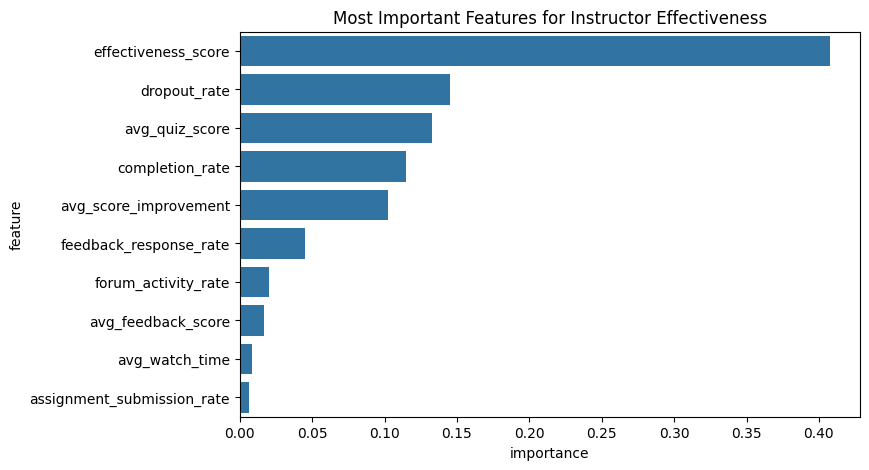

In [38]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

importance = importance.sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='importance', y='feature')
plt.title("Most Important Features for Instructor Effectiveness")
plt.show()

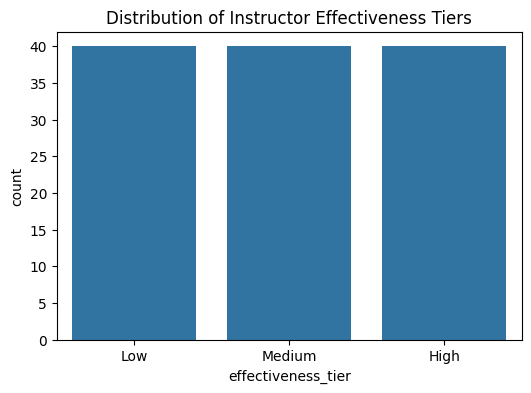

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x=instructor_df['effectiveness_tier'])
plt.title("Distribution of Instructor Effectiveness Tiers")
plt.show()

The model can help EdTech platforms identify instructors who consistently produce strong learning outcomes and engagement.
Insights from this analysis could help guide instructor training programs, curriculum improvements, and personalized support for instructors.

While predictive models can provide useful insights, they should not be the sole basis for evaluating instructor performance.
Teaching effectiveness is influenced by course difficulty, student backgrounds, and other contextual factors that may not be captured in the dataset.